### ***727723EUAI109 : SANJAY M***

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1: Loss surface and gradients
def loss(w1, w2):
    return w1**2 + 10 * w2**2

def grad(w1, w2):
    return 2 * w1, 20 * w2

w1_start, w2_start = 8.0, 4.0
steps = 50

In [2]:
def run_gd(w1, w2, steps, lr_fn):
    traj = [(w1, w2)]
    for t in range(steps):
        lr = lr_fn(t)
        g1, g2 = grad(w1, w2)
        w1 -= lr * g1
        w2 -= lr * g2
        traj.append((w1, w2))
    return traj

traj_A = run_gd(w1_start, w2_start, steps, lr_fn=lambda t: 0.05)
traj_B = run_gd(w1_start, w2_start, steps, lr_fn=lambda t: 0.09)
traj_C = run_gd(w1_start, w2_start, steps, lr_fn=lambda t: 0.05 / (1 + 0.1 * t))

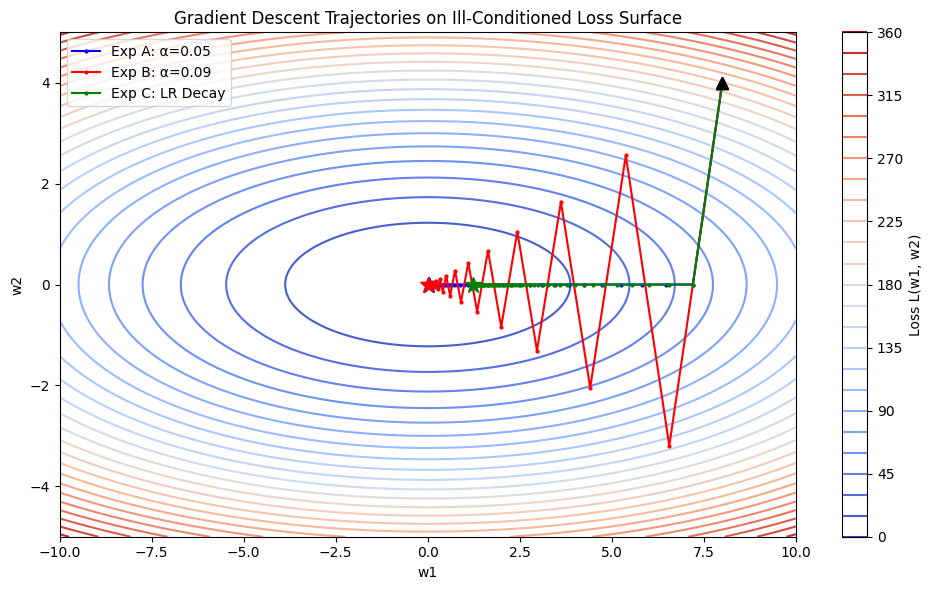

Exp A | Final (w1=0.0412, w2=0.0000) | Loss=0.001700
Exp B | Final (w1=0.0004, w2=0.0001) | Loss=0.000000
Exp C | Final (w1=1.2203, w2=0.0000) | Loss=1.489227


In [3]:
w1_range = np.linspace(-10, 10, 400)
w2_range = np.linspace(-5, 5, 400)
W1, W2 = np.meshgrid(w1_range, w2_range)
L = loss(W1, W2)

fig, ax = plt.subplots(figsize=(10, 6))
contour = ax.contour(W1, W2, L, levels=30, cmap='coolwarm')
plt.colorbar(contour, ax=ax, label='Loss L(w1, w2)')

for traj, color, label in [
    (traj_A, 'blue',  'Exp A: α=0.05'),
    (traj_B, 'red',   'Exp B: α=0.09'),
    (traj_C, 'green', 'Exp C: LR Decay'),
]:
    xs, ys = zip(*traj)
    ax.plot(xs, ys, color=color, marker='o', markersize=2, label=label)
    ax.plot(xs[0],  ys[0],  'k^', markersize=8)   # start
    ax.plot(xs[-1], ys[-1], color=color, marker='*', markersize=12)  # end

ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_title('Gradient Descent Trajectories on Ill-Conditioned Loss Surface')
ax.legend()
plt.tight_layout()
plt.show()

for name, traj in [('A', traj_A), ('B', traj_B), ('C', traj_C)]:
    w1f, w2f = traj[-1]
    print(f"Exp {name} | Final (w1={w1f:.4f}, w2={w2f:.4f}) | Loss={loss(w1f, w2f):.6f}")